# Coding Ninjas 10X – AI/ML Recruitment (First Years)
# Task 1: Exploratory Data Analysis & Preprocessing – Auto MPG

**Goal:** explore, clean and analyse the Auto MPG dataset (fuel efficiency of ~400 cars from 1970–1982) and export an analysis-ready CSV for Task 2.

**Columns:** `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin`, `car_name`.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 120)

## Part A – Data Exploration

In [3]:
# Load the Auto MPG dataset (public copy of the UCI Auto MPG data).
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
raw = pd.read_csv(URL)
raw = raw.rename(columns={"name": "car_name"})      # use the column name from the task sheet
df = raw.copy()
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [4]:
print("Rows, columns:", df.shape)
print("\nData types:",df.dtypes)
print("\nMissing values per column:"); print(df.isna().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("Repeated car names:", df.car_name.duplicated().sum(), "(same model, different year/spec - checked in Part B)")

Rows, columns: (398, 9)

Data types: mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
car_name         object
dtype: object

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Fully duplicated rows: 0
Repeated car names: 93 (same model, different year/spec - checked in Part B)


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.51,7.82,9.0,17.50,23.0,29.00,46.6
cylinders,398.0,5.45,1.70,3.0,4.00,4.0,8.00,8.0
displacement,398.0,193.43,104.27,68.0,104.25,148.5,262.00,455.0
horsepower,392.0,104.47,38.49,46.0,75.00,93.5,126.00,230.0
weight,398.0,2970.42,846.84,1613.0,2223.75,2803.5,3608.00,5140.0
acceleration,398.0,15.57,2.76,8.0,13.82,15.5,17.18,24.8
model_year,398.0,76.01,3.70,70.0,73.00,76.0,79.00,82.0


In [6]:
df.describe(include="object").T

,count,unique,top,freq
origin,398,3,usa,249
car_name,398,305,ford pinto,6


### Column categorisation

| Column | Type | Description |
|---|---|---|
| `mpg` | Numerical – continuous | **Target**: fuel efficiency (miles per gallon) |
| `displacement` | Numerical – continuous | Engine volume (cubic inches) |
| `horsepower` | Numerical – continuous | Engine power (**has missing values**) |
| `weight` | Numerical – continuous (integer) | Vehicle weight (lbs) |
| `acceleration` | Numerical – continuous | Seconds taken to reach 60 mph (higher = slower car) |
| `cylinders` | Numerical – discrete / ordinal | Number of cylinders (3, 4, 5, 6, 8) – treated as a group in EDA |
| `model_year` | Numerical – discrete / ordinal | Year of manufacture (70–82, i.e. 1970–1982) |
| `origin` | Categorical – nominal | Region of manufacture (usa, europe, japan) |
| `car_name` | Categorical – identifier text | Make and model; not a useful predictor |

**Observations:** 398 rows and 9 columns. Only `horsepower` has missing values (6 rows). There are no fully duplicated rows.

## Part B – Data Preprocessing

### B1. Data types
The original UCI file stores missing horsepower as `'?'`, which turns the column into text. `pd.to_numeric(errors='coerce')` makes this robust to either source. `origin` is a nominal category and `cylinders`/`model_year` are kept numeric (they are ordered).

In [7]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df["origin"] = df["origin"].astype(str).str.lower().str.strip()
# If origin is coded 1/2/3 (original UCI file), map it to region names
df["origin"] = df["origin"].replace({"1": "usa", "2": "europe", "3": "japan"})
df["car_name"] = df["car_name"].astype(str).str.lower().str.strip()
df["origin"] = df["origin"].astype("category")
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,category
car_name,object


### B2. Missing values
The 6 rows with missing `horsepower` are inspected first.

In [8]:
missing_rows = df[df["horsepower"].isna()]
display(missing_rows)
print("Median horsepower by cylinders:")
print(df.groupby("cylinders")["horsepower"].median())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl


Median horsepower by cylinders:
cylinders
3     98.5
4     78.0
5     77.0
6    100.0
8    150.0
Name: horsepower, dtype: float64


**Decision:** only 6 of 398 rows (1.5%) are affected, so dropping them would waste data. Horsepower depends strongly on engine size, so a single global median would be crude. I **impute with the median horsepower of cars with the same number of cylinders** (median, not mean, because horsepower is right-skewed).

In [9]:
df["horsepower"] = df["horsepower"].fillna(df.groupby("cylinders")["horsepower"].transform("median"))
print("Missing values after imputation:", df.isna().sum().sum())
df.loc[missing_rows.index, ["car_name", "cylinders", "displacement", "horsepower"]]

Missing values after imputation: 0


,car_name,cylinders,displacement,horsepower
32,ford pinto,4,98.0,78.0
126,ford maverick,6,200.0,100.0
330,renault lecar deluxe,4,85.0,78.0
336,ford mustang cobra,4,140.0,78.0
354,renault 18i,4,100.0,78.0
374,amc concord dl,4,151.0,78.0


### B3. Duplicate and suspicious records

In [10]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicates ignoring car_name (identical specs):", df.duplicated(subset=[c for c in df.columns if c != "car_name"]).sum())

# Same name appearing several times - are these true duplicates or different model years?
rep = df[df.car_name.duplicated(keep=False)].sort_values("car_name")
print("\nRows sharing a car_name:", len(rep))
display(rep.head(8))

# Physically implausible values?
checks = {
    "mpg <= 0": (df.mpg <= 0).sum(),
    "weight <= 0": (df.weight <= 0).sum(),
    "horsepower <= 0": (df.horsepower <= 0).sum(),
    "displacement <= 0": (df.displacement <= 0).sum(),
    "acceleration <= 0": (df.acceleration <= 0).sum(),
    "model_year outside 70-82": (~df.model_year.between(70, 82)).sum(),
    "cylinders not in {3,4,5,6,8}": (~df.cylinders.isin([3, 4, 5, 6, 8])).sum(),
}
print("\nInvalid-value checks:"); print(pd.Series(checks))

Exact duplicate rows: 0
Duplicates ignoring car_name (identical specs): 0

Rows sharing a car_name: 149


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
315,24.3,4,151.0,90.0,3003,20.1,80,usa,amc concord
257,19.4,6,232.0,90.0,3210,17.2,78,usa,amc concord
107,18.0,6,232.0,100.0,2789,15.0,73,usa,amc gremlin
169,20.0,6,232.0,100.0,2914,16.0,75,usa,amc gremlin
33,19.0,6,232.0,100.0,2634,13.0,71,usa,amc gremlin
24,21.0,6,199.0,90.0,2648,15.0,70,usa,amc gremlin
99,18.0,6,232.0,100.0,2945,16.0,73,usa,amc hornet
127,19.0,6,232.0,100.0,2901,16.0,74,usa,amc hornet



Invalid-value checks:
mpg <= 0                        0
weight <= 0                     0
horsepower <= 0                 0
displacement <= 0               0
acceleration <= 0               0
model_year outside 70-82        0
cylinders not in {3,4,5,6,8}    0
dtype: int64


**Findings:** there are no exact duplicates. Repeated names are different model years/engine configurations (e.g. the same Ford model in different years), so they are legitimate and are **kept**. No physically impossible values were found. Statistical outliers are examined in Part C.

### B4. Analysis-ready dataset
`model_year` is stored as 70–82; I add `year_full` (1970–1982) for readability and keep the original column as well.

In [11]:
df["year_full"] = df["model_year"] + 1900
df = df.reset_index(drop=True)
print("Original shape :", raw.shape)
print("Cleaned shape  :", df.shape)
print("\nChanges made:")
print(" 1. Renamed 'name' -> 'car_name'")
print(" 2. Converted horsepower to numeric; imputed", len(missing_rows), "missing values with median horsepower per cylinder group")
print(" 3. Standardised text (lower-case, stripped); origin -> category")
print(" 4. Added 'year_full' (1970-1982)")
print(" 5. No rows removed (no exact duplicates or invalid records)")
df.info()

Original shape : (398, 9)
Cleaned shape  : (398, 10)

Changes made:
 1. Renamed 'name' -> 'car_name'
 2. Converted horsepower to numeric; imputed 6 missing values with median horsepower per cylinder group
 3. Standardised text (lower-case, stripped); origin -> category
 4. Added 'year_full' (1970-1982)
 5. No rows removed (no exact duplicates or invalid records)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           398 non-null    float64 
 1   cylinders     398 non-null    int64   
 2   displacement  398 non-null    float64 
 3   horsepower    398 non-null    float64 
 4   weight        398 non-null    int64   
 5   acceleration  398 non-null    float64 
 6   model_year    398 non-null    int64   
 7   origin        398 non-null    category
 8   car_name      398 non-null    object  
 9   year_full     398 non-null    int64   
dt

## Part C – Exploratory Data Analysis

### C1. Distribution of MPG

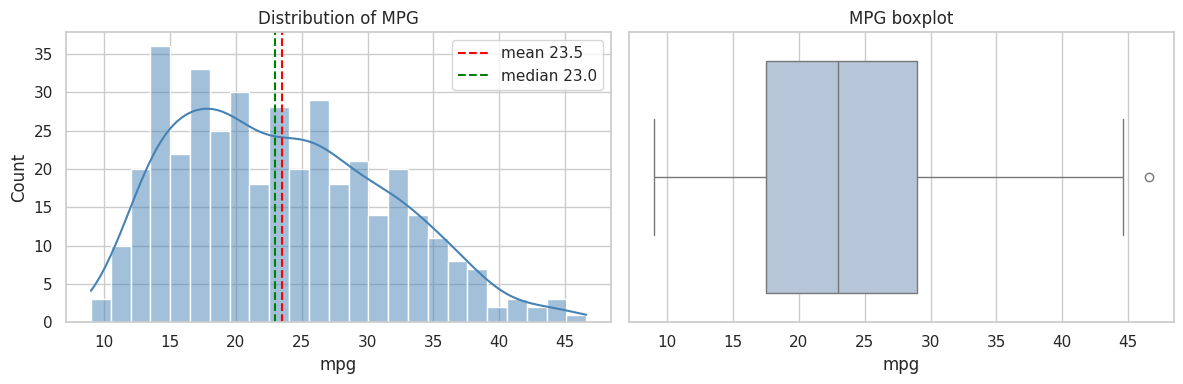

mean=23.51, median=23.00, std=7.82, min=9.0, max=46.6, skew=0.46


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.mpg, bins=25, kde=True, ax=ax[0], color="steelblue")
ax[0].axvline(df.mpg.mean(), color="red", ls="--", label=f"mean {df.mpg.mean():.1f}")
ax[0].axvline(df.mpg.median(), color="green", ls="--", label=f"median {df.mpg.median():.1f}")
ax[0].legend(); ax[0].set_title("Distribution of MPG")
sns.boxplot(x=df.mpg, ax=ax[1], color="lightsteelblue"); ax[1].set_title("MPG boxplot")
plt.tight_layout(); plt.show()
print(f"mean={df.mpg.mean():.2f}, median={df.mpg.median():.2f}, std={df.mpg.std():.2f}, "
      f"min={df.mpg.min()}, max={df.mpg.max()}, skew={df.mpg.skew():.2f}")

MPG is **mildly right-skewed** (mean > median), centred around 20–30 mpg, with a second, smaller cluster of very efficient cars in the high 30s–40s.

### C2. Key vehicle characteristics: displacement, horsepower, weight, acceleration

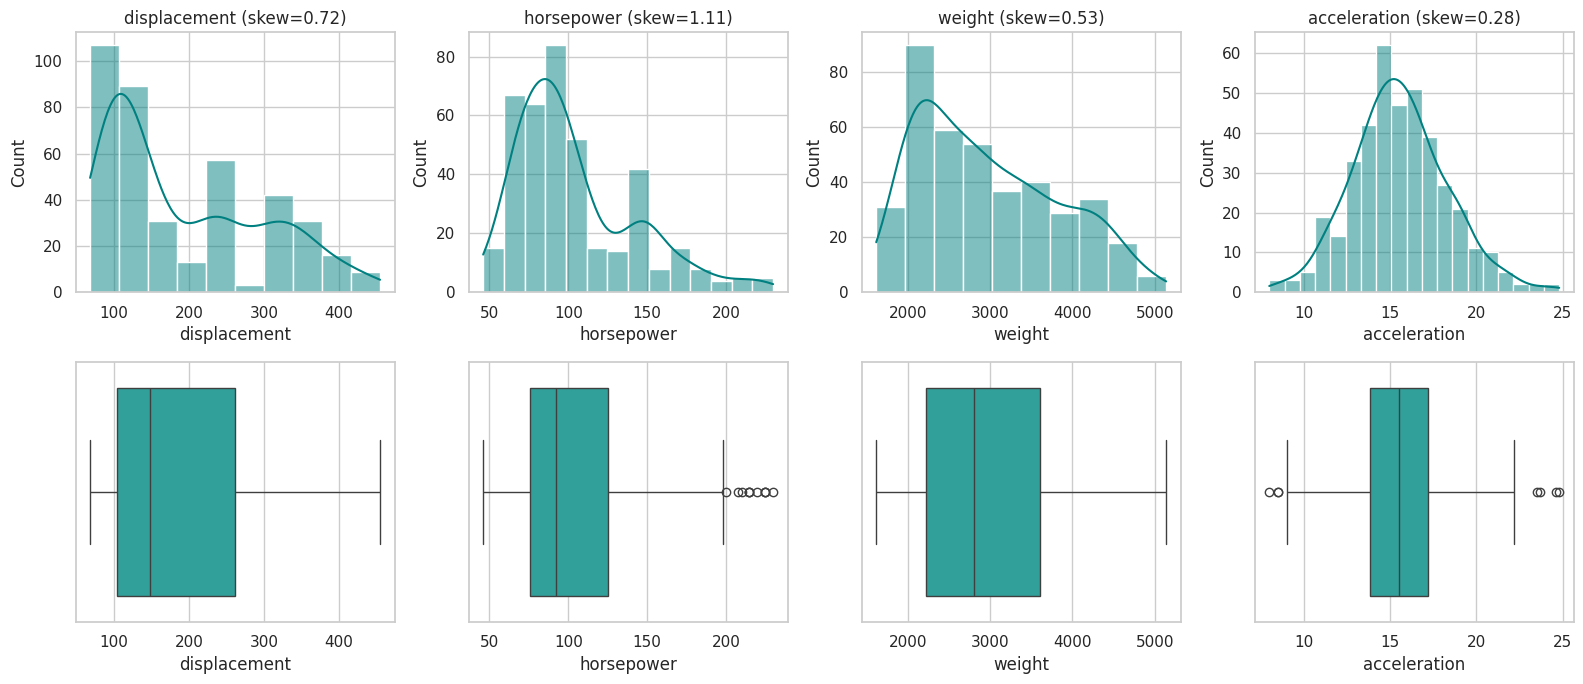

,displacement,horsepower,weight,acceleration
count,398.00,398.00,398.00,398.00
mean,193.43,104.13,2970.42,15.57
std,104.27,38.31,846.84,2.76
min,68.00,46.00,1613.00,8.00
25%,104.25,76.00,2223.75,13.82
50%,148.50,92.00,2803.50,15.50
75%,262.00,125.00,3608.00,17.18
max,455.00,230.00,5140.00,24.80


In [13]:
feats = ["displacement", "horsepower", "weight", "acceleration"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, f in enumerate(feats):
    sns.histplot(df[f], kde=True, ax=axes[0, i], color="teal")
    axes[0, i].set_title(f"{f} (skew={df[f].skew():.2f})")
    sns.boxplot(x=df[f], ax=axes[1, i], color="lightseagreen")
plt.tight_layout(); plt.show()
df[feats].describe().round(2)

`displacement`, `horsepower` and `weight` are **right-skewed** (many small cars, fewer big-engine cars). `acceleration` is roughly symmetric/normal with a few slow and fast extremes.

### C3. Relationship between MPG and other variables

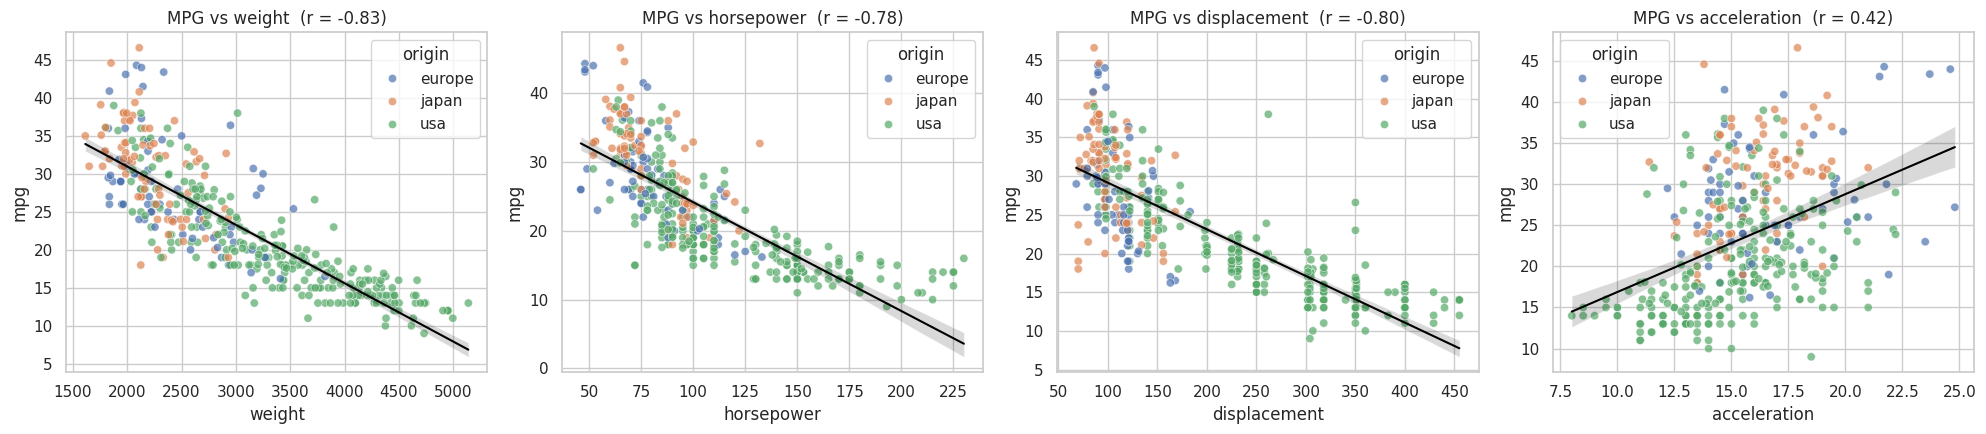

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, f in zip(axes, ["weight", "horsepower", "displacement", "acceleration"]):
    sns.scatterplot(data=df, x=f, y="mpg", hue="origin", alpha=0.7, ax=ax)
    sns.regplot(data=df, x=f, y="mpg", scatter=False, color="black", ax=ax, line_kws={"lw": 1.5})
    r = df[f].corr(df["mpg"])
    ax.set_title(f"MPG vs {f}  (r = {r:.2f})")
plt.tight_layout(); plt.show()

- **Weight, horsepower, displacement**: strong *negative*, slightly **curved** (non-linear) relationship – heavier/more powerful cars burn more fuel.
- **Acceleration**: weak positive relationship; slow acceleration (a high number) goes with small, efficient engines.

### C4. Comparing MPG across groups (cylinders, origin, model year)

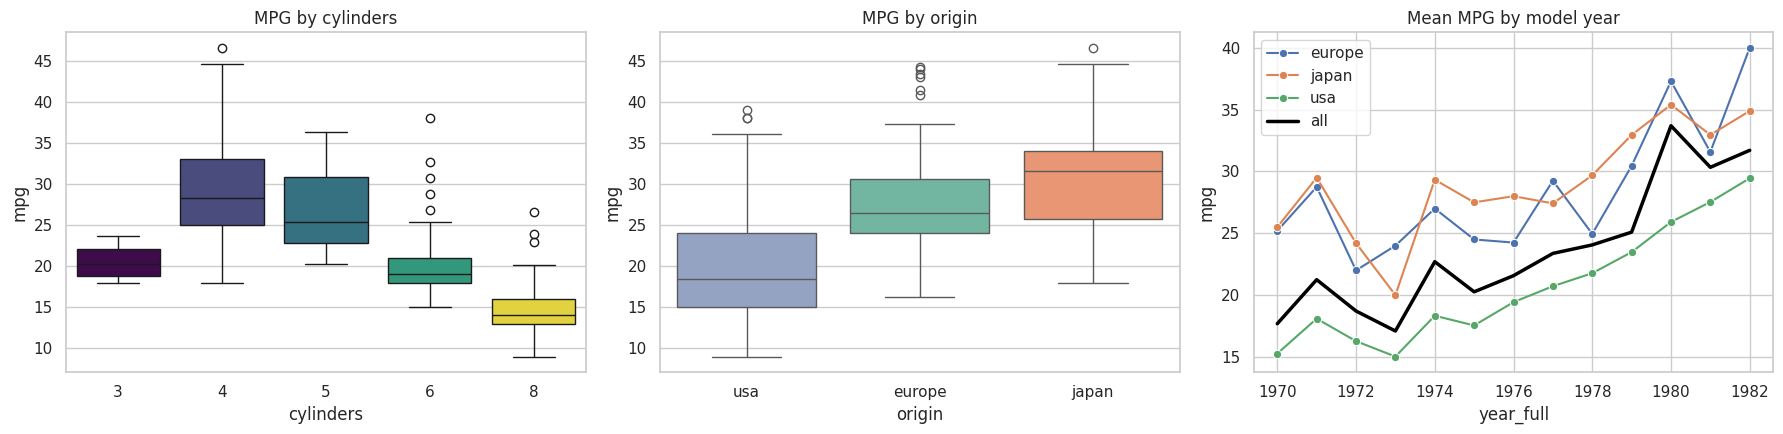

           count  mean  median
cylinders                     
3              4  20.6    20.2
4            204  29.3    28.2
5              3  27.4    25.4
6             84  20.0    19.0
8            103  15.0    14.0 

        count  mean  median
origin                     
europe     70  27.9    26.5
japan      79  30.5    31.6
usa       249  20.1    18.5
ANOVA across origins: F = 98.5, p-value = 1.92e-35


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
sns.boxplot(data=df, x="cylinders", y="mpg", ax=axes[0], palette="viridis", hue="cylinders", legend=False)
axes[0].set_title("MPG by cylinders")
sns.boxplot(data=df, x="origin", y="mpg", order=["usa", "europe", "japan"], ax=axes[1], palette="Set2", hue="origin", legend=False)
axes[1].set_title("MPG by origin")
sns.lineplot(data=df, x="year_full", y="mpg", hue="origin", marker="o", errorbar=None, ax=axes[2])
sns.lineplot(data=df, x="year_full", y="mpg", color="black", lw=2.5, errorbar=None, ax=axes[2], label="all")
axes[2].set_title("Mean MPG by model year")
plt.tight_layout(); plt.show()

print(df.groupby("cylinders").mpg.agg(["count", "mean", "median"]).round(1), "\n")
print(df.groupby("origin", observed=True).mpg.agg(["count", "mean", "median"]).round(1))

# Is the origin difference statistically significant, or could it just be random chance?
# A one-way ANOVA test compares the average MPG across the 3 origin groups.
# A small p-value (< 0.05) means the difference between groups is very unlikely to be due to chance.
groups = [g.mpg.values for _, g in df.groupby("origin", observed=True)]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA across origins: F = {f_stat:.1f}, p-value = {p_value:.2e}")

- **Cylinders:** MPG falls steadily from 4 → 6 → 8 cylinders (4-cyl cars average ~29 mpg vs ~15 mpg for V8s). The 3- and 5-cylinder groups have only 4 and 3 cars, so they are not reliable to interpret.
- **Origin:** Japanese and European cars are much more efficient than American ones, and the difference is statistically significant.
- **Model year:** average MPG rises over time, with a clear jump around 1980.

### C5. Correlation analysis

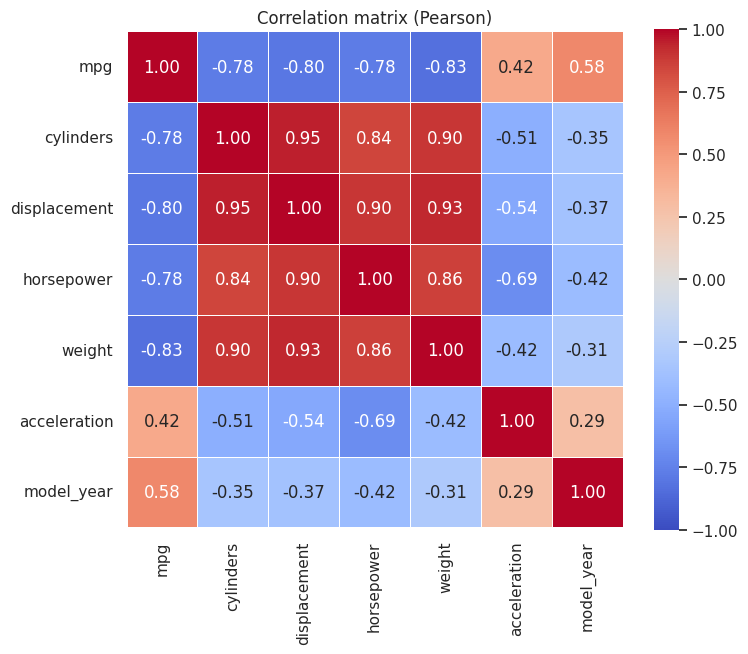

weight         -0.83
displacement   -0.80
horsepower     -0.78
cylinders      -0.78
acceleration    0.42
model_year      0.58
Name: mpg, dtype: float64


In [16]:
num = df[["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]]
corr = num.corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Correlation matrix (Pearson)"); plt.show()
print(corr["mpg"].drop("mpg").sort_values().round(2))

- MPG is most strongly (negatively) correlated with **weight (-0.83)**, **displacement (-0.80)**, **horsepower** and **cylinders (~ -0.78)**.
- `model_year` is the strongest *positive* correlate (+0.58).
- **Multicollinearity:** cylinders, displacement, horsepower and weight are all very highly correlated with each other (r ≈ 0.84–0.95) – bigger engines are in heavier cars. This matters for Task 2.

### C6. Outliers and unusual observations

In [17]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return s[(s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)]

for col in ["mpg", "horsepower", "acceleration", "weight", "displacement"]:
    print(f"{col:13s} IQR outliers: {len(iqr_outliers(df[col]))}")

print("\nTop MPG outliers:")
display(df.loc[iqr_outliers(df.mpg).index, ["car_name", "mpg", "cylinders", "horsepower", "weight", "model_year", "origin"]].sort_values("mpg", ascending=False))
print("Top horsepower outliers:")
display(df.loc[iqr_outliers(df.horsepower).index, ["car_name", "mpg", "horsepower", "weight", "cylinders", "model_year"]].sort_values("horsepower", ascending=False).head(8))
print("Extreme acceleration values:")
display(pd.concat([df.nsmallest(2, "acceleration"), df.nlargest(2, "acceleration")])[["car_name", "acceleration", "horsepower", "cylinders", "weight"]])

# Investigate: is the very high-MPG car just an overall extreme, or unusual *for its weight*?
# Compare each car's MPG to the average MPG of other cars in the same 500 lb weight bucket.
df["weight_bucket"] = pd.cut(df.weight, bins=range(1500, 5500, 500))
df["bucket_avg_mpg"] = df.groupby("weight_bucket", observed=True)["mpg"].transform("mean")
df["mpg_vs_bucket"] = df.mpg - df.bucket_avg_mpg
print("Cars that are most unusual (highest MPG) compared to similar-weight cars:")
display(df.nlargest(5, "mpg_vs_bucket")[["car_name", "mpg", "weight", "weight_bucket", "bucket_avg_mpg", "mpg_vs_bucket"]].round(1))
df = df.drop(columns=["weight_bucket", "bucket_avg_mpg", "mpg_vs_bucket"])

mpg           IQR outliers: 1
horsepower    IQR outliers: 11
acceleration  IQR outliers: 7
weight        IQR outliers: 0
displacement  IQR outliers: 0

Top MPG outliers:


,car_name,mpg,cylinders,horsepower,weight,model_year,origin
322,mazda glc,46.6,4,65.0,2110,80,japan


Top horsepower outliers:


,car_name,mpg,horsepower,weight,cylinders,model_year
116,pontiac grand prix,16.0,230.0,4278,8,73
13,buick estate wagon (sw),14.0,225.0,3086,8,70
8,pontiac catalina,14.0,225.0,4425,8,70
95,buick electra 225 custom,12.0,225.0,4951,8,73
6,chevrolet impala,14.0,220.0,4354,8,70
7,plymouth fury iii,14.0,215.0,4312,8,70
25,ford f250,10.0,215.0,4615,8,70
94,chrysler new yorker brougham,13.0,215.0,4735,8,73


Extreme acceleration values:


,car_name,acceleration,horsepower,cylinders,weight
11,plymouth 'cuda 340,8.0,160.0,8,3609
7,plymouth fury iii,8.5,215.0,8,4312
299,peugeot 504,24.8,71.0,4,3190
394,vw pickup,24.6,52.0,4,2130


Cars that are most unusual (highest MPG) compared to similar-weight cars:


,car_name,mpg,weight,weight_bucket,bucket_avg_mpg,mpg_vs_bucket
387,oldsmobile cutlass ciera (diesel),38.0,3015,"(3000, 3500]",19.9,18.1
322,mazda glc,46.6,2110,"(2000, 2500]",29.6,17.0
325,vw rabbit c (diesel),44.3,2085,"(2000, 2500]",29.6,14.7
394,vw pickup,44.0,2130,"(2000, 2500]",29.6,14.4
326,vw dasher (diesel),43.4,2335,"(2000, 2500]",29.6,13.8


**Investigation:**
- The highest-MPG cars (e.g. *mazda glc*, *honda civic*, *vw rabbit diesel*) are all **1980 small 4-cylinder Japanese/European cars** – genuine values caused by small light engines (and a diesel), not errors. **They are kept.**
- The highest-horsepower cars (Pontiac Grand Prix/Catalina, Buick Electra) are big American V8s with very low MPG – again real, consistent with the trend.
- The very slow and very fast accelerating cars (e.g. *plymouth 'cuda 340*, *peugeot 504*) are consistent with their power/engine.
- Since no outlier was a data error, none are removed; removing them would discard real information about the dataset's range.

## Part D – Individual Analysis

### Question
**Did cars become more fuel-efficient over 1970–1982 mainly because manufacturers made them lighter, or were cars of a *similar weight* also more efficient by the end of the period?**

(Approach: compare the mean weight and mean MPG in an early period, 1970-75, against a later period, 1978-82. Then look only at cars that fall in the *same weight range* in both periods, and compare their MPG. If weight explained everything, similar-weight cars should show similar MPG in both periods. If MPG is still higher in the later period, something else must have improved too.)

         weight   mpg
era                  
1970-75  3198.4  19.4
1978-82  2778.3  27.0


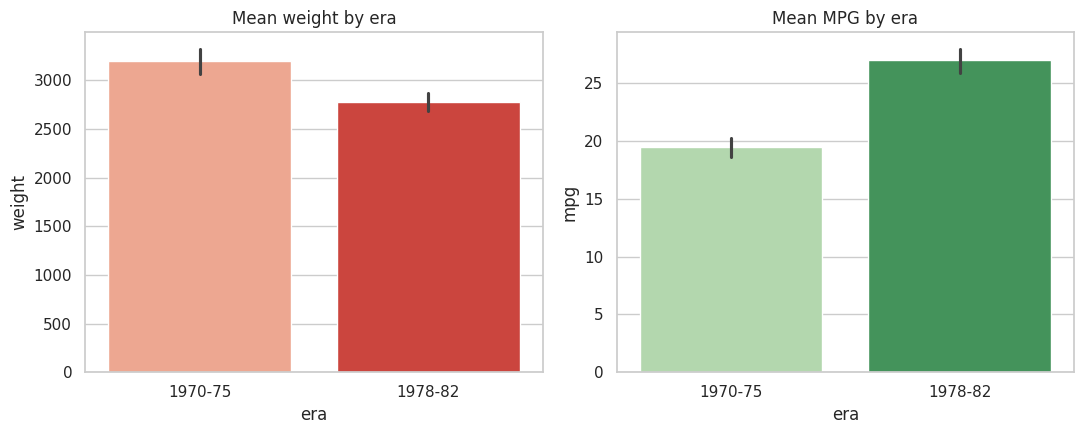

In [18]:
# Split into an early era and a late era
df["era"] = np.where(df.model_year <= 75, "1970-75", "1978-82")
era_df = df[df.era.isin(["1970-75", "1978-82"])]
era_summary = era_df.groupby("era")[["weight", "mpg"]].mean().round(1)
print(era_summary)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(data=era_df, x="era", y="weight", ax=ax[0], hue="era", palette="Reds", legend=False)
ax[0].set_title("Mean weight by era")
sns.barplot(data=era_df, x="era", y="mpg", ax=ax[1], hue="era", palette="Greens", legend=False)
ax[1].set_title("Mean MPG by era")
plt.tight_layout(); plt.show()

Cars weighing 2500-3000 lb, split by era:
         count  mean
era                 
1970-75     31  21.3
1978-82     53  26.4


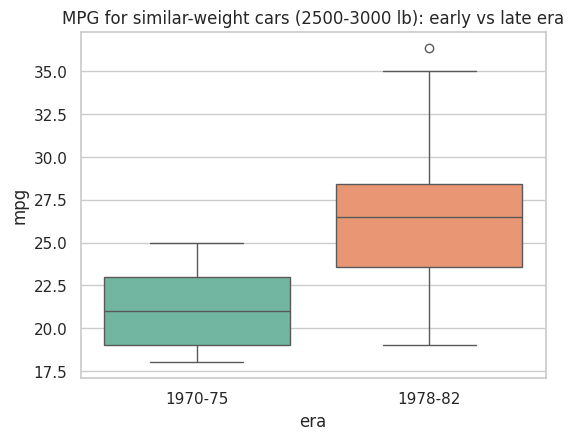

In [19]:
# Now compare MPG for cars in the SAME weight band (2500-3000 lb) in both eras,
# so weight is no longer a factor and we can isolate the effect of the era alone.
band = era_df[era_df.weight.between(2500, 3000)]
same_weight_summary = band.groupby("era")["mpg"].agg(["count", "mean"]).round(1)
print("Cars weighing 2500-3000 lb, split by era:")
print(same_weight_summary)

plt.figure(figsize=(6, 4.5))
sns.boxplot(data=band, x="era", y="mpg", hue="era", palette="Set2", legend=False)
plt.title("MPG for similar-weight cars (2500-3000 lb): early vs late era")
plt.show()

### Conclusion
Cars did get noticeably lighter between the two eras, which explains part of the MPG improvement. **But weight is not the whole story**: even when we only look at cars of the *same weight* (2500–3000 lb), the later cars (1978–82) still averaged clearly higher MPG than the earlier ones (1970–75). So the improvement in fuel efficiency came from **both** lighter cars **and** cars becoming more efficient at a given weight. (Caveat: this compares a fairly small number of cars per group, so it points to an association rather than a proven cause — a plausible real-world driver is the fuel-economy push following the 1973 oil crisis.)

## Part E – Insights & Export

In [20]:
r = df.select_dtypes("number").corr()["mpg"]
g_cyl = df.groupby("cylinders").mpg.mean(); g_org = df.groupby("origin", observed=True).mpg.mean()
display(Markdown(f'''
### Key findings
1. **Dataset:** {df.shape[0]} cars × {df.shape[1]-1} columns after cleaning; only `horsepower` had missing values (6 rows, imputed by cylinder-group median); no duplicates or impossible values.
2. **MPG distribution:** mean {df.mpg.mean():.1f}, median {df.mpg.median():.1f}, range {df.mpg.min():.0f}–{df.mpg.max():.1f}; mildly right-skewed (skew {df.mpg.skew():.2f}).
3. **Weight is the strongest predictor of MPG** (r = {r['weight']:.2f}), followed by displacement ({r['displacement']:.2f}), horsepower ({r['horsepower']:.2f}) and cylinders ({r['cylinders']:.2f}). The relationship is negative and slightly **curved**, not perfectly linear.
4. **Cylinders:** 4-cylinder cars average {g_cyl[4]:.1f} mpg vs {g_cyl[6]:.1f} (6-cyl) and {g_cyl[8]:.1f} (8-cyl) – roughly half the efficiency for V8s.
5. **Origin:** Japan ({g_org['japan']:.1f} mpg) and Europe ({g_org['europe']:.1f}) beat the USA ({g_org['usa']:.1f}); this is significant (ANOVA p<0.001), and reflects the USA making most of the large-engine cars.
6. **Time trend:** average MPG rose from {df[df.model_year==70].mpg.mean():.1f} (1970) to {df[df.model_year==82].mpg.mean():.1f} (1982), with a jump around 1980.
7. **Efficiency improved beyond weight loss:** even for cars of similar weight (2500-3000 lb), the later era (1978-82) still averaged higher MPG than the earlier era (1970-75) (see Part D).
8. **Multicollinearity:** engine size, horsepower, cylinders and weight are highly inter-correlated – important for interpreting regression coefficients.
'''))


### Key findings
1. **Dataset:** 398 cars × 10 columns after cleaning; only `horsepower` had missing values (6 rows, imputed by cylinder-group median); no duplicates or impossible values.
2. **MPG distribution:** mean 23.5, median 23.0, range 9–46.6; mildly right-skewed (skew 0.46).
3. **Weight is the strongest predictor of MPG** (r = -0.83), followed by displacement (-0.80), horsepower (-0.78) and cylinders (-0.78). The relationship is negative and slightly **curved**, not perfectly linear.
4. **Cylinders:** 4-cylinder cars average 29.3 mpg vs 20.0 (6-cyl) and 15.0 (8-cyl) – roughly half the efficiency for V8s.
5. **Origin:** Japan (30.5 mpg) and Europe (27.9) beat the USA (20.1); this is significant (ANOVA p<0.001), and reflects the USA making most of the large-engine cars.
6. **Time trend:** average MPG rose from 17.7 (1970) to 31.7 (1982), with a jump around 1980.
7. **Efficiency improved beyond weight loss:** even for cars of similar weight (2500-3000 lb), the later era (1978-82) still averaged higher MPG than the earlier era (1970-75) (see Part D).
8. **Multicollinearity:** engine size, horsepower, cylinders and weight are highly inter-correlated – important for interpreting regression coefficients.


In [23]:
# Final cleaned dataset (drop temporary helper column) and export
df_clean = df.drop(columns=["era"])
df_clean.to_csv("auto_mpg_cleaned.csv", index=False)
print("Saved auto_mpg_cleaned.csv with shape", df_clean.shape)
print("Missing values:", df_clean.isna().sum().sum(), "| Duplicates:", df_clean.duplicated().sum())
df_clean.head()

# In Google Colab, uncomment to download the file:
from google.colab import files; files.download("auto_mpg_cleaned.csv")

Saved auto_mpg_cleaned.csv with shape (398, 10)
Missing values: 0 | Duplicates: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>